## Forced 2D RMHD turbulence

This demonstrates the Ornstein-Uhlenbeck forcing scheme: a stochastic forcing that injects
a fixed target power into a shell of large-scale perpendicular wavenumbers, sustaining
turbulence indefinitely instead of letting it freely decay (contrast with `orzag-tang-2D.ipynb`).

We use `forcing_mode="elsasser"` (forces z+ = phi+psi and z- = phi-psi independently, each
at its own target power via `forcing_power_elsasser=(eps_plus, eps_minus)`), rather than
`"momentum"` (forces phi only). With a quiescent (all-zero) start in 2D, momentum-mode
forcing leaves psi exactly zero forever (its only source in 2D is the nonlinear bracket term
-bracket(gphi,gpsi), which vanishes identically when psi=0), so it's really just 2D hydro,
not MHD turbulence. Elsasser mode excites both phi and psi from the start.


In [1]:
#imports
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import os

import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
#lower-level helper reused here for a total-energy diagnostic in the same physical units
#that forcing_power is defined in (see physics/shared_physics.py)
from jax_rmhd.physics import shared_physics

jr.init_cluster()


jax is using 64bit precision.


In [2]:
#grid + physical parameters
nx = 256
ny = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi

nsnap = 1000
t_snap = 0.5
t_end = 20.0
cfl_safety = 0.5
spatial_dimensions = 2
snap_path = "data/forced-turbulence-2D/"

#hyperviscosity; could be tuned
visc = 1e-9
res = 1e-9
hyper = 3

#forcing parameters
forcing = True
forcing_mode = "elsasser"   
forcing_power_elsasser = (0.3,0.3)         #target energy injection rate 
forcing_tau = 1.0           #O-U decorrelation time of the forcing pattern
fshell = (1, 3)             #force the shell 1 <= |k_perp|/dk < 3 (large scales)
forcing_seed = 234          # random seed
forcing_scale_max = 1.0     #caps the energy added per timestep


params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, diss=(visc, res),
                        hyper=hyper, cfl_safety=cfl_safety, dims=spatial_dimensions,
                        forcing=forcing, forcing_mode=forcing_mode, forcing_power_elsasser=forcing_power_elsasser,
                        forcing_tau=forcing_tau, fshell=fshell, forcing_seed=forcing_seed,
                        forcing_scale_max=forcing_scale_max)

mngr = jr.snapshot_manager_setup(params=params,snap_path=snap_path, nsnap=nsnap)

kgrid = jr.setup_kgrids(params)


### Initial condition

Start from a quiescent plasma (all fields zero) and let the forcing spin up turbulence
from rest -- there's no need to seed any structure by hand.


In [3]:
def zero_init(x, y):
    return jnp.zeros((2,) + jnp.broadcast_shapes(x.shape, y.shape))

state = jr.initialize(zero_init, params)

nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
print("nblock estimate: " + str(nblock))


nblock estimate: 10


In [ ]:
#run the simulation, saving snapshots along the way
end_state = jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap, t_end=t_end,
                              mngr=mngr, save=True)


Saving initial state as snapshot 0
0.33850990556011207
0.44230703232299384
0.5367445009251769
Saving snapshot 1
0.6236644099441668
0.7034600158406387
0.7771884181449066
0.8465686192088547
0.9124353505223557
0.9750006169577959
1.0348207854073308
1.0923002601911278
Saving snapshot 2
1.147728675735728
1.2014050366325462
1.2534207194674205
1.3038305815693647
1.3530622190242756
1.4016765330334602
1.450049195633861
1.4986016410689884
1.5473356646449161
1.5960358130084735
Saving snapshot 3
1.6437830036699637
1.6906994269635782
1.7371581595715575
1.7825941780837873
1.826987292264404
1.8706205708951393
1.9136887039529125
1.9564289390785796
1.999203661465578
2.042155860896102
2.084539181165879
2.1255401403329635
Saving snapshot 4
2.165327671998417
2.2040626313119347
2.241868704937851
2.2787976317040326
2.314728748639024
2.349084408873179
2.381909212026179
2.4139490144099565
2.4452891394426945
2.4763564303179866
2.5071325189915403
2.5376516844092483
2.567791352175119
2.5974430799828427
2.62696131

: 

In [ ]:
#this is just to check that the snapshots save and load correctly, including the key (which is some weird jax object)

last_isnap = max(mngr.all_steps())
print(f"Reloading snapshot {last_isnap} and comparing against the in-memory end_state...")
reloaded = sn.load_snapshot(last_isnap, mngr, params)

t_diff = float(jnp.abs(reloaded.t - end_state.t))
fields_diff = float(jnp.max(jnp.abs(reloaded.fields - end_state.fields)))
forcing_state_diff = float(jnp.max(jnp.abs(reloaded.forcing_state - end_state.forcing_state)))
key_match = bool(jnp.array_equal(jax.random.key_data(reloaded.forcing_key),
                                  jax.random.key_data(end_state.forcing_key)))

print(f"  t:                        reloaded={float(reloaded.t):.6f}, end_state={float(end_state.t):.6f}, diff={t_diff:.3e}")
print(f"  fields max abs diff:      {fields_diff:.3e}")
print(f"  forcing_state max abs diff: {forcing_state_diff:.3e}")
print(f"  forcing_key matches:      {key_match}")

ok = (t_diff < 1e-8) and (fields_diff < 1e-8) and (forcing_state_diff < 1e-8) and key_match
print()
print("PASS: reloaded snapshot matches the in-memory end_state" if ok
      else "FAIL: reloaded snapshot does NOT match the in-memory end_state")


Reloading snapshot 40 and comparing against the in-memory end_state...
  t:                        reloaded=20.001903, end_state=20.001903, diff=0.000e+00
  fields max abs diff:      0.000e+00
  forcing_state max abs diff: 0.000e+00
  forcing_key matches:      True

PASS: reloaded snapshot matches the in-memory end_state


### Vorticity snapshot

A quick look at the perpendicular vorticity ($\zeta = \nabla_\perp^2 \phi$) at the end of
the run, same convention as `orzag-tang-2D.ipynb`.


Text(0.5, 1.0, 'Vorticity at t=20.00')

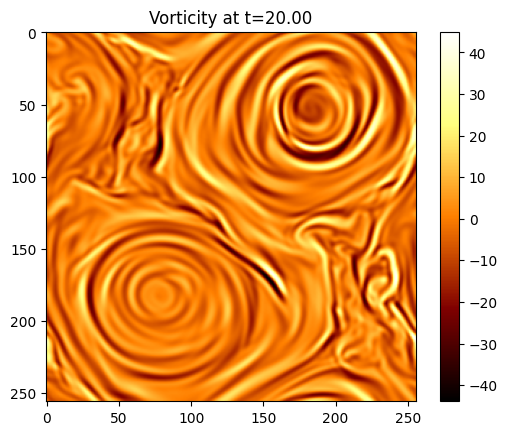

In [6]:
vort = ft.irfft2(-kgrid.ksq()*end_state.fields[0, 0, :, :])
plt.imshow(vort, cmap="afmhot")
plt.colorbar()
plt.title(f"Vorticity at t={float(end_state.t):.2f}")


### Perpendicular energy spectrum

Dashed vertical lines mark the forcing shell (`fshell`).


Text(0.5, 1.0, 'Spectrum at t=20.00')

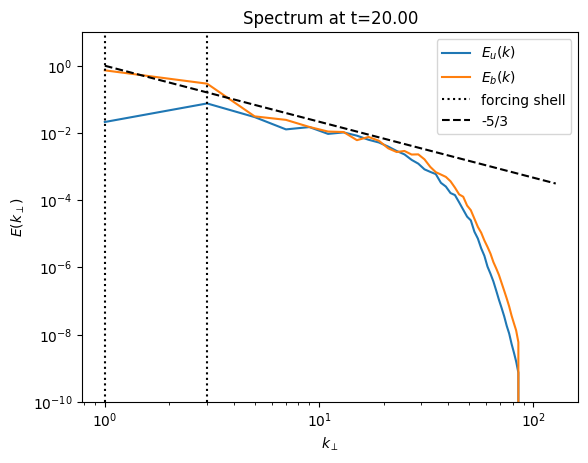

In [7]:
bins, su, sb = diag.perpspec(end_state, kgrid, params)

plt.loglog(bins, su, label=r'$E_u(k)$')
plt.loglog(bins, sb, label=r'$E_b(k)$')
kunit = min(2*jnp.pi/params.Lx, 2*jnp.pi/params.Ly)
plt.axvline(params.fshell[0]*kunit, color='k', linestyle=':', label='forcing shell')
plt.axvline(params.fshell[1]*kunit, color='k', linestyle=':')
plt.loglog(bins,bins**-(5./3.),'k--',label='-5/3')
plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.ylim(1e-10,10)
plt.legend()
plt.title(f"Spectrum at t={float(end_state.t):.2f}")


### Diagnostics vs time

In [8]:
ts = []
E_kin_list = []
E_mag_list = []
psi_sq_list = []
for isnap in sorted(mngr.all_steps()):
    snap = sn.load_snapshot(isnap, mngr, params)
    phik, psik = snap.fields[0], snap.fields[1]
    E_kin = 0.5*shared_physics.perp_inner_product(phik, phik, kgrid, params)
    E_mag = 0.5*shared_physics.perp_inner_product(psik, psik, kgrid, params)
    psi_sq = shared_physics.perp_mean_square(psik, psik, kgrid, params)
    ts.append(float(snap.t))
    E_kin_list.append(float(E_kin))
    E_mag_list.append(float(E_mag))
    psi_sq_list.append(float(psi_sq))


### Kinetic and magnetic energy vs time

Text(0.5, 1.0, 'Kinetic and magnetic energy vs time')

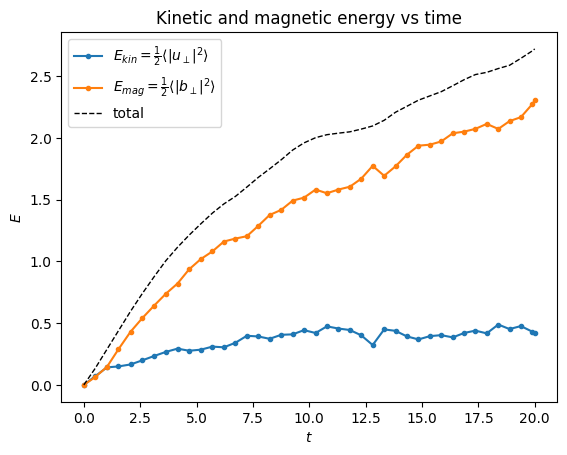

In [9]:
plt.plot(ts, E_kin_list, marker='o', markersize=3, label=r'$E_{kin}=\frac{1}{2}\langle|u_\perp|^2\rangle$')
plt.plot(ts, E_mag_list, marker='o', markersize=3, label=r'$E_{mag}=\frac{1}{2}\langle|b_\perp|^2\rangle$')
plt.plot(ts, [ek + em for ek, em in zip(E_kin_list, E_mag_list)], 'k--', linewidth=1, label='total')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.legend()
plt.title("Kinetic and magnetic energy vs time")


### `<psi^2>` vs time

Unlike energy (which cascades forward/direct in 2D MHD), the mean-square flux function
inverse-cascades to large scales (Fyfe-Montgomery-Ting / Pouquet).


Text(0.5, 1.0, 'Mean-square flux function $\\langle\\psi^2\\rangle$ vs time')

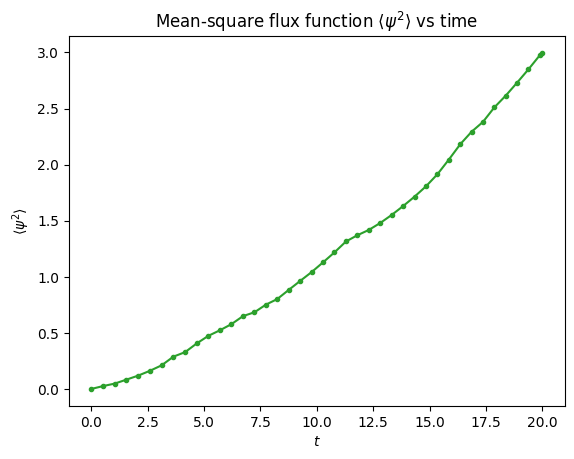

In [10]:
plt.plot(ts, psi_sq_list, marker='o', markersize=3, color='C2')
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle \psi^2 \rangle$')
plt.title(r"Mean-square flux function $\langle\psi^2\rangle$ vs time")


Other things to try:
- Compare `forcing_mode="elsasser"` (with `forcing_power_elsasser=(eps_plus, eps_minus)`)
  against `"momentum"` -- do the resulting spectra/energy balance differ?
- Move `fshell` to smaller scales (larger `nmin`,`nmax`) and see how the spectrum below
  the forcing shell changes (inverse cascade signatures, if any, vs. direct cascade).
- Should also rewrite for 3D.


### Making a GIF: vorticity + spectrum over time

In [ ]:
gif_frames_dir = os.path.abspath(snap_path + "gif_frames")
os.makedirs(gif_frames_dir, exist_ok=True)
kunit = min(2*jnp.pi/params.Lx, 2*jnp.pi/params.Ly)

#fix scales across frames using the final snapshot
vort_final = ft.irfft2(-kgrid.ksq()*end_state.fields[0, 0, :, :])
vort_scale = float(jnp.max(jnp.abs(vort_final)))
spec_ymin, spec_ymax = 1e-10, 10.0
bins_final, _, _ = diag.perpspec(end_state, kgrid, params)

all_isnaps = sorted(mngr.all_steps())
for i, isnap in enumerate(all_isnaps):
    snap = sn.load_snapshot(isnap, mngr, params)
    vort = ft.irfft2(-kgrid.ksq()*snap.fields[0, 0, :, :])
    bins, su, sb = diag.perpspec(snap, kgrid, params)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax1.imshow(vort, cmap="afmhot", vmin=-vort_scale, vmax=vort_scale)
    ax1.set_title(f"Vorticity, t={float(snap.t):.2f}")

    ax2.loglog(bins, su, label=r'$E_u(k)$')
    ax2.loglog(bins, sb, label=r'$E_b(k)$')
    ax2.axvline(params.fshell[0]*kunit, color='k', linestyle=':', label='forcing shell')
    ax2.axvline(params.fshell[1]*kunit, color='k', linestyle=':')
    ax2.loglog(bins, bins**-(5./3.), 'k--', linewidth=1, label='-5/3')
    ax2.set_xlim(float(bins_final[0]), float(bins_final[-1]))
    ax2.set_ylim(spec_ymin, spec_ymax)
    ax2.set_xlabel(r'$k_\perp$')
    ax2.set_ylabel(r'$E(k_\perp)$')
    ax2.legend(fontsize=8)
    ax2.set_title(f"Spectrum, t={float(snap.t):.2f}")

    plt.tight_layout()
    plt.savefig(os.path.join(gif_frames_dir, str(i).zfill(4) + ".png"))
    plt.close(fig)

print(f"Wrote {len(all_isnaps)} frames to {gif_frames_dir}")


In [ ]:
gif_out = os.path.abspath(os.path.join(snap_path, "forced-turbulence-2D.gif"))
os.system(f'magick -delay 10 -loop 0 "{gif_frames_dir}"/*.png "{gif_out}"')
print(f"Wrote GIF to {gif_out}" if os.path.exists(gif_out)
      else "GIF not created -- is ImageMagick (`magick`) installed? Frame PNGs are still in gif_frames_dir.")
